In [42]:
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
import os
# import tensorflow as tf
# import random

In [ ]:
# START FROM HERE!!

raw_image_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/raw_images/'
ground_truth_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/segmentations/'
unet_directory = 'C:/Users/Mittal/Desktop/thoracic_seg/cylinder_niipredictions/'

raw_images = sorted(os.listdir(raw_image_directory))
segmentations = sorted(os.listdir(ground_truth_directory))
unet_predictions = sorted(os.listdir(unet_directory))

image_dataset = []
mask_dataset = []
unet_prediction_dataset = []
image_names = []
toSkip = ["A21_02_FatFrac_IDEAL_IQ_PDFF_11", 
          "A21_12_FatFrac_2D_FAM_BH_18", 
          "A21_13_New_FatFrac_IDEAL_IQ_PDFF_13", 
          "A21_16_New_FatFrac_IDEAL_IQ_PDFF_16", 
          "A21_16_New_FatFrac_IDEAL_IQ_PDFF_24", 
          "A21_19_FatFrac_IDEAL_IQ_PDFF_14"]

for image_name in raw_images:    
    if (image_name.split('.')[1] == 'nii'):
        if(image_name.split('.')[0] not in toSkip):
            base_name = image_name.split('.')[0]
            image = nib.load(raw_image_directory+image_name).get_fdata()
            segmentation = nib.load(ground_truth_directory+image_name).get_fdata()
            new_mask = np.copy(segmentation)
            new_mask[segmentation == 1] = 0
            unet = nib.load(unet_directory+image_name).get_fdata()
            unet = np.squeeze(unet, axis=0)
            label_map = np.argmax(unet, axis=2)  # shape: (H, W, Z)
            label_map[label_map == 1] = 0

            image_dataset.append(np.array(image))
            mask_dataset.append(np.array(new_mask))
            unet_prediction_dataset.append(np.array(label_map))
            image_names.append(base_name)

In [45]:
print(mask_dataset[0].shape)
print(unet_prediction_dataset[0].shape)
print(image_names[0], np.unique(mask_dataset[0]))
print(image_names[0], np.unique(unet_prediction_dataset[0]))

(256, 256, 25)
(256, 256, 25)
A21_02_FatFrac_2D_FAM_BH_14 [0. 2. 3. 4. 5. 6.]
A21_02_FatFrac_2D_FAM_BH_14 [0 2 3 4 5 6]


In [46]:
num_cyl = 5            # cylinders 1–5
gt_labels = [2,3,4,5,6]
unet_labels = [2,3,4,5,6]

stats = {}

# slices = {
#     "MidSlice": 0,
#     "MidSlice+1": 1,
#     "MidSlice-1": -1
# }

for i in range(len(image_dataset)):
    img = image_dataset[i]
    gt_seg = mask_dataset[i]
    unet_seg = unet_prediction_dataset[i]
    name = image_names[i]
    
    z_has_cylinder = np.any(np.isin(gt_seg, gt_labels), axis=(0,1))
    cylinder_slices = np.where(z_has_cylinder)[0]

    if len(cylinder_slices) == 0:
        continue 

    if len(cylinder_slices) < 3:
        print(f"Skipping {name}: not enough cylinder slices")
        continue

    z_start = cylinder_slices[0]
    z_end   = cylinder_slices[-1]

    z_mid1 = cylinder_slices[len(cylinder_slices)//2 - 1]
    z_mid2 = cylinder_slices[len(cylinder_slices)//2]
    z_mid3 = cylinder_slices[len(cylinder_slices)//2 + 1]

    middle_slices = [z_mid1, z_mid2, z_mid3]
    
    for z in middle_slices:
        key = f"{name}_{z}"
        stats[key] = {}
                
        # GT
        for c, lbl in enumerate(gt_labels):
            mask = (gt_seg[:,:,z] == lbl)
            vals = img[:,:,z][mask]
            stats[key][("GT", f"Cylinder{c+1}", "Mean")] = np.mean(vals) if vals.size else 0
            stats[key][("GT", f"Cylinder{c+1}", "Std")]  = np.std(vals)  if vals.size else 0
        
        # U-Net
        for c, lbl in enumerate(unet_labels):
            mask = (unet_seg[:,:,z] == lbl)
            vals = img[:,:,z][mask]
            stats[key][("UNet", f"Cylinder{c+1}", "Mean")] = np.mean(vals) if vals.size else 0
            stats[key][("UNet", f"Cylinder{c+1}", "Std")]  = np.std(vals)  if vals.size else 0

In [47]:
import pandas as pd

# df = pd.DataFrame.from_dict(stats, orient='index')
# df.columns = pd.MultiIndex.from_tuples(df.columns, names=['Model', 'Cylinder', 'Stat'])
# df.index.name = "Image_Slice"
# # df = df.drop(columns=[('GroundTruth', 'Cylinder 6', 'Mean'), ('GroundTruth', 'Cylinder 6', 'Std')])
# df

df = pd.DataFrame.from_dict(stats, orient='index')
df.index.name = "Image_Slice"
df.columns = pd.MultiIndex.from_tuples(df.columns, names=["Model","Cylinder","Stat"])

# Drop any rows with NaN
# df = df.dropna()

print("\nDataframe shape:", df.shape)
df



Dataframe shape: (120, 20)


Model                                      GT                                  \
Cylinder                            Cylinder1            Cylinder2              
Stat                                     Mean       Std       Mean        Std   
Image_Slice                                                                     
A21_02_FatFrac_2D_FAM_BH_14_9       41.761589  6.659862  33.413333   6.202351   
A21_02_FatFrac_2D_FAM_BH_14_10      41.812903  7.282136  33.264901   6.543489   
A21_02_FatFrac_2D_FAM_BH_14_11      41.094937  8.441750  33.095890   5.916460   
A21_02_FatFrac_2D_FAM_BH_18_4       42.535948  8.337666  33.355705   7.954631   
A21_02_FatFrac_2D_FAM_BH_18_5       41.278481  6.091988  33.082192   6.896005   
...                                       ...       ...        ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  40.165414  5.152093  29.368421   4.959192   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50  39.832117  6.117546  30.255474   4.789022   
A21_31_FatFrac_3D_Iron_Quant_17_32  41.479730  6.489565  30.439189   9.044355   
A21_31_FatFrac_3D_Iron_Quant_17_33  41.055556  9.830822  31.108108  10.306214   
A21_31_FatFrac_3D_Iron_Quant_17_34  40.555556  9.399895   0.000000   0.000000   

Model                                                                         \
Cylinder                            Cylinder3            Cylinder4             
Stat                                     Mean       Std       Mean       Std   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_9       23.680851  4.848512  13.601399  4.896324   
A21_02_FatFrac_2D_FAM_BH_14_10      23.412587  4.085329  13.683099  4.906692   
A21_02_FatFrac_2D_FAM_BH_14_11      22.713287  3.988835  12.957447  3.956989   
A21_02_FatFrac_2D_FAM_BH_18_4       24.111888  4.758658  13.659722  4.830694   
A21_02_FatFrac_2D_FAM_BH_18_5       23.230216  4.490304  13.392857  3.914618   
...                                       ...       ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  20.868613  3.448934  10.313869  3.846985   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50  19.511278  3.408562  10.372263  2.543081   
A21_31_FatFrac_3D_Iron_Quant_17_32  21.006757  4.855335  11.550296  7.573632   
A21_31_FatFrac_3D_Iron_Quant_17_33  20.858108  4.753392  11.165680  7.761748   
A21_31_FatFrac_3D_Iron_Quant_17_34  20.094595  4.884252  12.295858  8.061600   

Model                                                        UNet            \
Cylinder                           Cylinder5            Cylinder1             
Stat                                    Mean       Std       Mean       Std   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_9       0.219697  1.982172  41.305195  5.857981   
A21_02_FatFrac_2D_FAM_BH_14_10      0.156716  1.988228  40.838509  7.241101   
A21_02_FatFrac_2D_FAM_BH_14_11      0.432836  2.060458  40.417722  8.546385   
A21_02_FatFrac_2D_FAM_BH_18_4      -0.104000  2.607141  42.125000  8.214127   
A21_02_FatFrac_2D_FAM_BH_18_5       0.079710  2.525412  40.812865  6.541819   
...                                      ...       ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  1.609589  2.001278  40.175182  5.879443   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50 -0.978102  1.680577  39.220588  5.395656   
A21_31_FatFrac_3D_Iron_Quant_17_32 -0.141892  1.913713  40.542484  6.832245   
A21_31_FatFrac_3D_Iron_Quant_17_33 -0.831081  1.943070  40.344156  7.173526   
A21_31_FatFrac_3D_Iron_Quant_17_34 -1.054054  1.667592  40.285714  7.572776   

Model                                                                         \
Cylinder                            Cylinder2            Cylinder3             
Stat                                     Mean       Std       Mean       Std   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_9       32.848684  5.528348  23.386207  5.043516 

In [48]:
gt_df = df.xs('GT', axis=1, level='Model')
unet_df = df.xs('UNet', axis=1, level='Model')

gtAllZero = (gt_df==0).all(axis=1)
gtAllNonZero = (gt_df!=0).all(axis=1)
unetAllZero = (unet_df==0).all(axis=1)
unetAllNonZero = (unet_df!=0).all(axis=1)
df = df[(gtAllNonZero & unetAllNonZero) | (gtAllZero & unetAllZero)]
df

Model                                      GT                                  \
Cylinder                            Cylinder1            Cylinder2              
Stat                                     Mean       Std       Mean        Std   
Image_Slice                                                                     
A21_02_FatFrac_2D_FAM_BH_14_9       41.761589  6.659862  33.413333   6.202351   
A21_02_FatFrac_2D_FAM_BH_14_10      41.812903  7.282136  33.264901   6.543489   
A21_02_FatFrac_2D_FAM_BH_14_11      41.094937  8.441750  33.095890   5.916460   
A21_02_FatFrac_2D_FAM_BH_18_4       42.535948  8.337666  33.355705   7.954631   
A21_02_FatFrac_2D_FAM_BH_18_5       41.278481  6.091988  33.082192   6.896005   
...                                       ...       ...        ...        ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_48  40.838710  4.515899  30.321918   5.604469   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  40.165414  5.152093  29.368421   4.959192   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50  39.832117  6.117546  30.255474   4.789022   
A21_31_FatFrac_3D_Iron_Quant_17_32  41.479730  6.489565  30.439189   9.044355   
A21_31_FatFrac_3D_Iron_Quant_17_33  41.055556  9.830822  31.108108  10.306214   

Model                                                                         \
Cylinder                            Cylinder3            Cylinder4             
Stat                                     Mean       Std       Mean       Std   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_9       23.680851  4.848512  13.601399  4.896324   
A21_02_FatFrac_2D_FAM_BH_14_10      23.412587  4.085329  13.683099  4.906692   
A21_02_FatFrac_2D_FAM_BH_14_11      22.713287  3.988835  12.957447  3.956989   
A21_02_FatFrac_2D_FAM_BH_18_4       24.111888  4.758658  13.659722  4.830694   
A21_02_FatFrac_2D_FAM_BH_18_5       23.230216  4.490304  13.392857  3.914618   
...                                       ...       ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_48  21.253333  3.981937  10.631579  2.639987   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  20.868613  3.448934  10.313869  3.846985   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50  19.511278  3.408562  10.372263  2.543081   
A21_31_FatFrac_3D_Iron_Quant_17_32  21.006757  4.855335  11.550296  7.573632   
A21_31_FatFrac_3D_Iron_Quant_17_33  20.858108  4.753392  11.165680  7.761748   

Model                                                        UNet            \
Cylinder                           Cylinder5            Cylinder1             
Stat                                    Mean       Std       Mean       Std   
Image_Slice                                                                   
A21_02_FatFrac_2D_FAM_BH_14_9       0.219697  1.982172  41.305195  5.857981   
A21_02_FatFrac_2D_FAM_BH_14_10      0.156716  1.988228  40.838509  7.241101   
A21_02_FatFrac_2D_FAM_BH_14_11      0.432836  2.060458  40.417722  8.546385   
A21_02_FatFrac_2D_FAM_BH_18_4      -0.104000  2.607141  42.125000  8.214127   
A21_02_FatFrac_2D_FAM_BH_18_5       0.079710  2.525412  40.812865  6.541819   
...                                      ...       ...        ...       ...   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_48  0.983871  1.135809  40.546099  5.476546   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49  1.609589  2.001278  40.175182  5.879443   
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50 -0.978102  1.680577  39.220588  5.395656   
A21_31_FatFrac_3D_Iron_Quant_17_32 -0.141892  1.913713  40.542484  6.832245   
A21_31_FatFrac_3D_Iron_Quant_17_33 -0.831081  1.943070  40.344156  7.173526   

Model                                                                         \
Cylinder                            Cylinder2            Cylinder3             
Stat                                     Mean       Std       Mean       Std   
Image_Slice                                                                    
A21_02_FatFrac_2D_FAM_BH_14_9       32.848684  5.528348  23.386207  5.043516 

In [49]:
# Save DataFrame to an Excel file
df.to_excel('stats4_dataframe.xlsx', index=True)  # Include index (file names)

In [80]:
import pandas as pd

all_data = pd.read_excel('stats4_dataframe.xlsx')
all_data = all_data[3:]
all_data.columns = (['image_name',
'ground_truth_1_mean', 'ground_truth_1_std', 
'ground_truth_2_mean', 'ground_truth_2_std', 
'ground_truth_3_mean', 'ground_truth_3_std', 
'ground_truth_4_mean', 'ground_truth_4_std', 
'ground_truth_5_mean', 'ground_truth_5_std',
'unet_1_mean', 'unet_1_std',
'unet_2_mean', 'unet_2_std',
'unet_3_mean', 'unet_3_std',
'unet_4_mean', 'unet_4_std',
'unet_5_mean', 'unet_5_std',])
all_data['unet_difference_1'] = all_data['unet_1_mean'] - all_data['ground_truth_1_mean']
all_data['unet_difference_2'] = all_data['unet_2_mean'] - all_data['ground_truth_2_mean']
all_data['unet_difference_3'] = all_data['unet_3_mean'] - all_data['ground_truth_3_mean']
all_data['unet_difference_4'] = all_data['unet_4_mean'] - all_data['ground_truth_4_mean']
all_data['unet_difference_5'] = all_data['unet_5_mean'] - all_data['ground_truth_5_mean']
all_data['unet_std_difference_1'] = all_data['unet_1_std'] - all_data['ground_truth_1_std']
all_data['unet_std_difference_2'] = all_data['unet_2_std'] - all_data['ground_truth_2_std']
all_data['unet_std_difference_3'] = all_data['unet_3_std'] - all_data['ground_truth_3_std']
all_data['unet_std_difference_4'] = all_data['unet_4_std'] - all_data['ground_truth_4_std']
all_data['unet_std_difference_5'] = all_data['unet_5_std'] - all_data['ground_truth_5_std']
all_data['unet_average_1'] = (all_data['unet_1_mean'] + all_data['ground_truth_1_mean']) /2
all_data['unet_average_2'] = (all_data['unet_2_mean'] + all_data['ground_truth_2_mean']) /2
all_data['unet_average_3'] = (all_data['unet_3_mean'] + all_data['ground_truth_3_mean']) /2
all_data['unet_average_4'] = (all_data['unet_4_mean'] + all_data['ground_truth_4_mean']) /2
all_data['unet_average_5'] = (all_data['unet_5_mean'] + all_data['ground_truth_5_mean']) /2

differences = all_data[['image_name', 'unet_difference_1', 'unet_difference_2', 'unet_difference_3', 'unet_difference_4', 'unet_difference_5', 'unet_std_difference_1', 'unet_std_difference_2', 'unet_std_difference_3', 'unet_std_difference_4', 'unet_std_difference_5', 'unet_average_1', 'unet_average_2', 'unet_average_3', 'unet_average_4', 'unet_average_5']]
differences.set_index('image_name', inplace=True)

In [81]:
# Extract single-column Series instead of DataFrame for easier comparisons
c1 = differences['unet_difference_1']
c2 = differences['unet_difference_2']
c3 = differences['unet_difference_3']
c4 = differences['unet_difference_4']
c5 = differences['unet_difference_5']

c1_avg = differences['unet_average_1']
c2_avg = differences['unet_average_2']
c3_avg = differences['unet_average_3']
c4_avg = differences['unet_average_4']
c5_avg = differences['unet_average_5']

# Define bounds for outlier detection ±2 std
def in_bounds(series):
    mean = series.mean()
    std = series.std()
    return (series > (mean - 3*std)) & (series < (mean + 3*std))

# Create masks for each cylinder
mask_1 = in_bounds(c1)
mask_2 = in_bounds(c2)
mask_3 = in_bounds(c3)
mask_4 = in_bounds(c4)
mask_5 = in_bounds(c5)

# Combine outlier masks (all must be True to keep row)
combined_mask = mask_1 & mask_2 & mask_3 & mask_4 & mask_5

# Create artifact mask (True where any of the conditions is True)
artifact_mask = ( (c1_avg < 50) & (c2_avg < 40) & (c3_avg < 30) & (c4_avg < 20) & (c5_avg < 10) )

# Final mask: keep rows that are *within bounds* AND flagged as artifact
final_mask = combined_mask & artifact_mask
removed_rows = differences[~final_mask]

# Filter differences once
differences = differences[final_mask]

In [85]:
print("Removed rows: ", len(removed_rows))
removed_rows[['unet_average_1','unet_average_2','unet_average_3','unet_average_4','unet_average_5']]

Removed rows:  8


,unet_average_1,unet_average_2,unet_average_3,unet_average_4,unet_average_5
image_name,,,,,
A21_03_FatFrac_2D_FAM_BH_17_5,43.525136,35.901955,24.846733,20.297394,10.836952
A21_03_FatFrac_3D_Iron_Quant_12_34,41.704889,29.271351,20.719573,9.962575,-0.097033
A21_15_New_FatFrac_3D_Iron_quant_15_38,42.11131,29.86684,21.475211,10.987936,1.262458
A21_15_New_FatFrac_3D_Iron_quant_15_39,41.97032,29.293396,20.596907,10.77296,0.630609
A21_15_New_FatFrac_3D_Iron_quant_15_40,41.40936,30.155777,20.922093,11.042907,1.061095
A21_15_New_FatFrac_IDEAL_IQ_PDFF_24_43,38.54291,30.368243,18.169944,10.604588,-1.156141
A21_15_New_FatFrac_IDEAL_IQ_PDFF_24_44,41.268822,31.641892,17.21624,12.479448,-2.959189
A21_17_New_FatFrac_IDEAL_IQ_PDFF_24_25,41.783198,30.141165,20.62958,9.459726,2.518883


In [83]:
differences

,unet_difference_1,unet_difference_2,unet_difference_3,unet_difference_4,unet_difference_5,unet_std_difference_1,unet_std_difference_2,unet_std_difference_3,unet_std_difference_4,unet_std_difference_5,unet_average_1,unet_average_2,unet_average_3,unet_average_4,unet_average_5
image_name,,,,,,,,,,,,,,,
A21_02_FatFrac_2D_FAM_BH_14_9,-0.456395,-0.564649,-0.294644,-0.492555,-0.011364,-0.80188,-0.674003,0.195003,-0.823635,0.184094,41.533392,33.131009,23.533529,13.355121,0.214015
A21_02_FatFrac_2D_FAM_BH_14_10,-0.974394,-0.632643,-0.196371,-0.676342,-0.013859,-0.041035,-0.798343,0.404209,-0.963692,0.094254,41.325706,32.948579,23.314402,13.344928,0.149787
A21_02_FatFrac_2D_FAM_BH_14_11,-0.677215,-1.178693,-0.069451,-0.674688,-0.067319,0.104635,0.14896,0.157033,-1.021585,0.101322,40.756329,32.506544,22.678561,12.620103,0.399177
A21_02_FatFrac_2D_FAM_BH_18_4,-0.410948,-0.123447,-0.413258,-0.004317,0.336394,-0.12354,0.034732,0.626977,0.286465,0.37323,42.330474,33.293981,23.905259,13.657564,0.064197
A21_02_FatFrac_2D_FAM_BH_18_5,-0.465616,-0.601929,-0.749953,-0.310099,0.173811,0.44983,0.319631,1.187412,0.45061,0.230981,41.045673,32.781227,22.855239,13.237808,0.166616
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A21_19_FatFrac_IDEAL_IQ_PDFF_22_48,-0.29261,-0.286707,0.052222,0.326168,0.131775,0.960647,0.196711,-0.103081,0.695426,0.85914,40.692404,30.178565,21.279444,10.794663,1.049759
A21_19_FatFrac_IDEAL_IQ_PDFF_22_49,0.009769,0.007465,0.131387,-0.711032,-0.217697,0.72735,1.380527,0.359877,0.245699,-0.160908,40.170298,29.372154,20.934307,9.958353,1.50074
A21_19_FatFrac_IDEAL_IQ_PDFF_22_50,-0.611529,0.287383,-0.270402,0.329865,0.187892,-0.72189,1.128713,0.33217,0.161642,0.135641,39.526353,30.399166,19.376077,10.537195,-0.884156


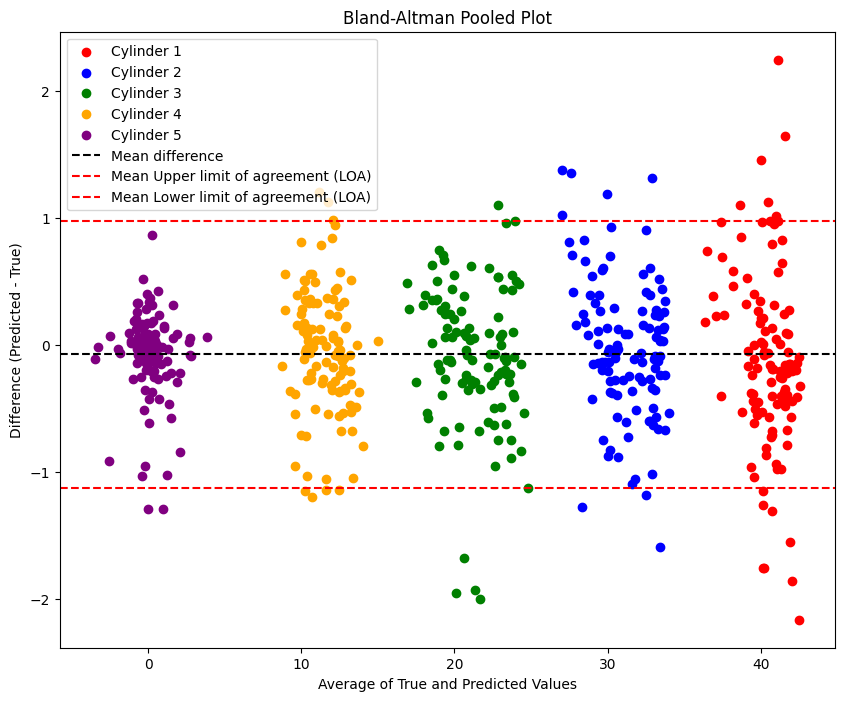

In [84]:
mean_difference1 = differences['unet_difference_1'].mean()
std_difference1 = differences['unet_difference_1'].std()

mean_difference2 = differences['unet_difference_2'].mean()
std_difference2 = differences['unet_difference_2'].std()

mean_difference3 = differences['unet_difference_3'].mean()
std_difference3 = differences['unet_difference_3'].std()

mean_difference4 = differences['unet_difference_4'].mean()
std_difference4 = differences['unet_difference_4'].std()

mean_difference5 = differences['unet_difference_5'].mean()
std_difference5 = differences['unet_difference_5'].std()

loa_upper1 = mean_difference1 + 1.96 * std_difference1
loa_lower1 = mean_difference1 - 1.96 * std_difference1

loa_upper2 = mean_difference2 + 1.96 * std_difference2
loa_lower2 = mean_difference2 - 1.96 * std_difference2

loa_upper3 = mean_difference3 + 1.96 * std_difference3
loa_lower3 = mean_difference3 - 1.96 * std_difference3

loa_upper4 = mean_difference4 + 1.96 * std_difference4
loa_lower4 = mean_difference4 - 1.96 * std_difference4

loa_upper5 = mean_difference5 + 1.96 * std_difference5
loa_lower5 = mean_difference5 - 1.96 * std_difference5

mean_difference = (mean_difference1 + mean_difference2 + mean_difference3 + mean_difference4 + mean_difference5)/5
mean_loa_upper = (loa_upper1 + loa_upper2 + loa_upper3 + loa_upper4 + loa_upper5)/5
mean_loa_lower = (loa_lower1 + loa_lower2 + loa_lower3 + loa_lower4 + loa_lower5)/5

plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_1'], differences['unet_difference_1'], color='red', label='Cylinder 1')
plt.scatter(differences['unet_average_2'], differences['unet_difference_2'], color='blue', label='Cylinder 2')
plt.scatter(differences['unet_average_3'], differences['unet_difference_3'], color='green', label='Cylinder 3')
plt.scatter(differences['unet_average_4'], differences['unet_difference_4'], color='orange', label='Cylinder 4')
plt.scatter(differences['unet_average_5'], differences['unet_difference_5'], color='purple', label='Cylinder 5')
plt.axhline(y=mean_difference, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=mean_loa_upper, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=mean_loa_lower, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Pooled Plot')
plt.legend()
plt.show()

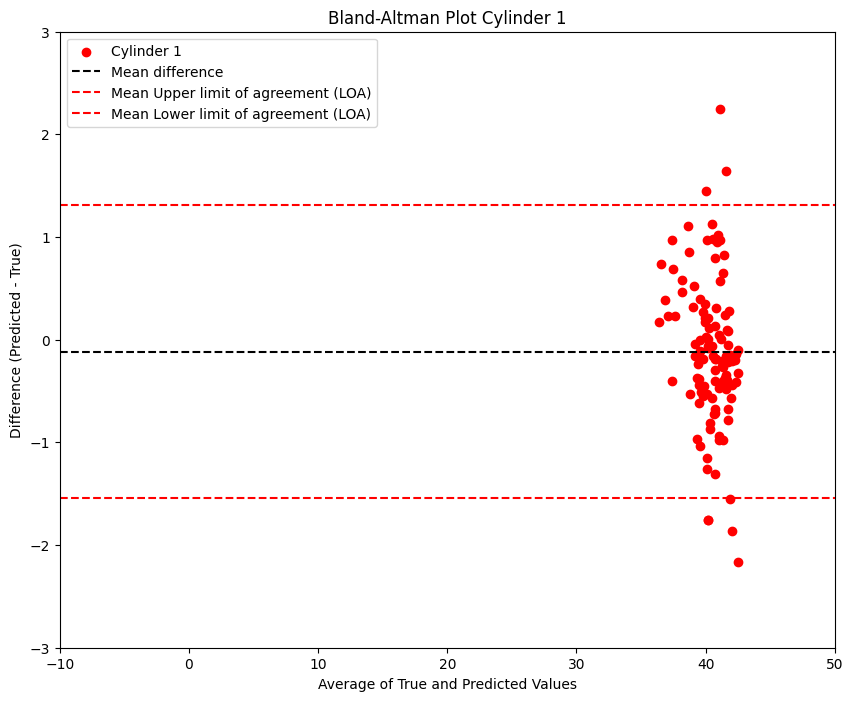

In [97]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_1'], differences['unet_difference_1'], color='red', label='Cylinder 1')
plt.axhline(y=mean_difference1, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper1, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower1, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 1')
plt.xlim(-10, 50)
plt.ylim(-3, 3)
plt.legend()
plt.show()

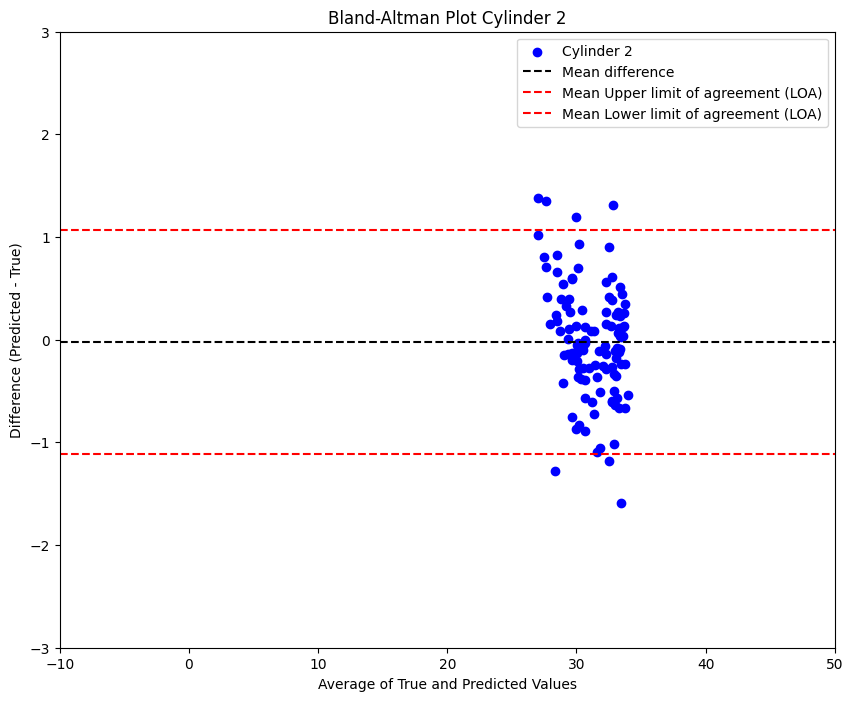

In [98]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_2'], differences['unet_difference_2'], color='blue', label='Cylinder 2')
plt.axhline(y=mean_difference2, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper2, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower2, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 2')
plt.xlim(-10, 50)
plt.ylim(-3, 3)
plt.legend()
plt.show()

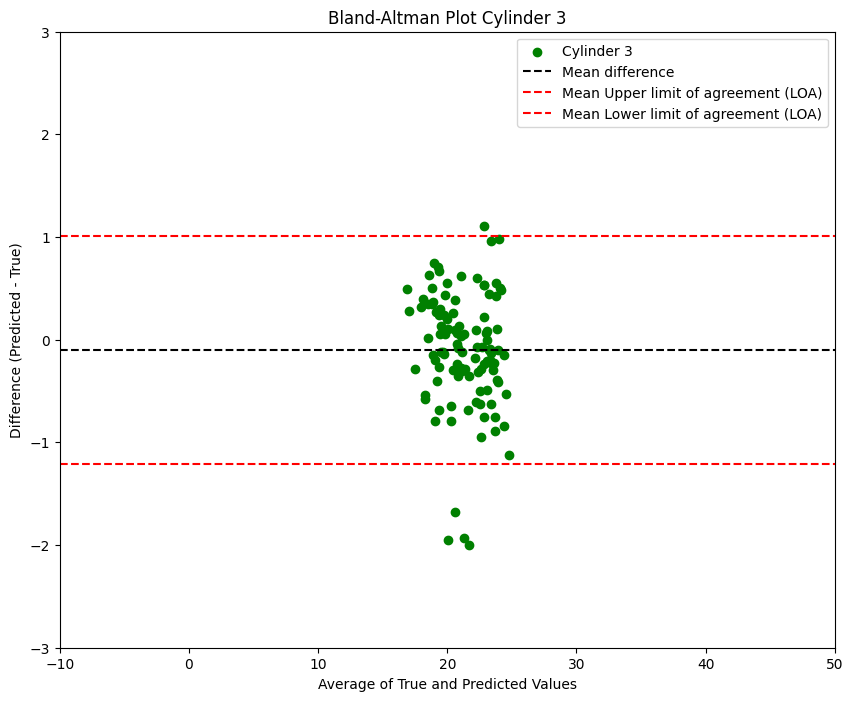

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_3'], differences['unet_difference_3'], color='green', label='Cylinder 3')
plt.axhline(y=mean_difference3, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper3, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower3, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 3')
plt.xlim(-10, 50)
plt.ylim(-3, 3)
plt.legend()
plt.show()

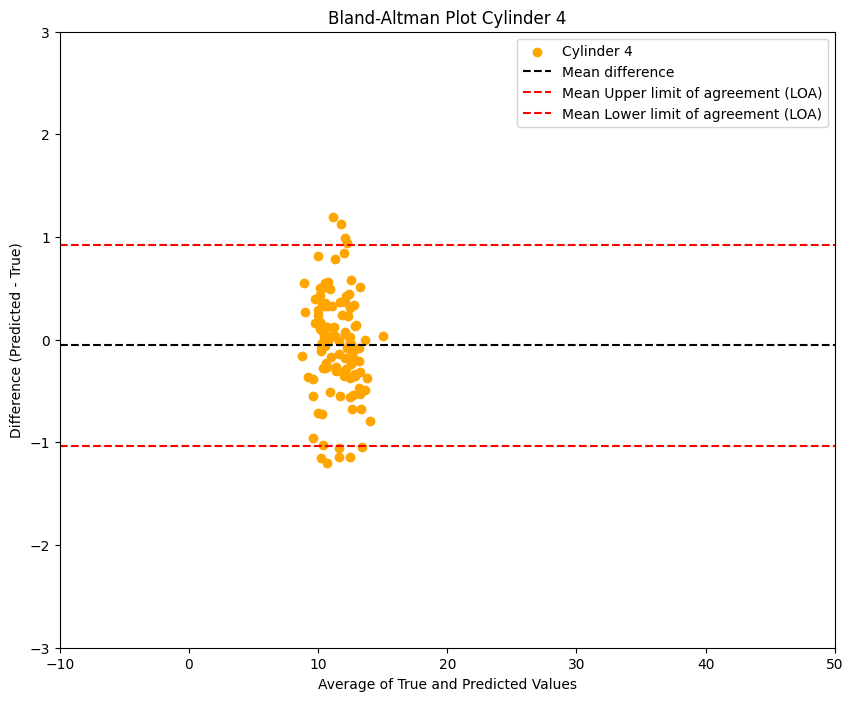

In [100]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_4'], differences['unet_difference_4'], color='orange', label='Cylinder 4')
plt.axhline(y=mean_difference4, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper4, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower4, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 4')
plt.xlim(-10, 50)
plt.ylim(-3, 3)
plt.legend()
plt.show()

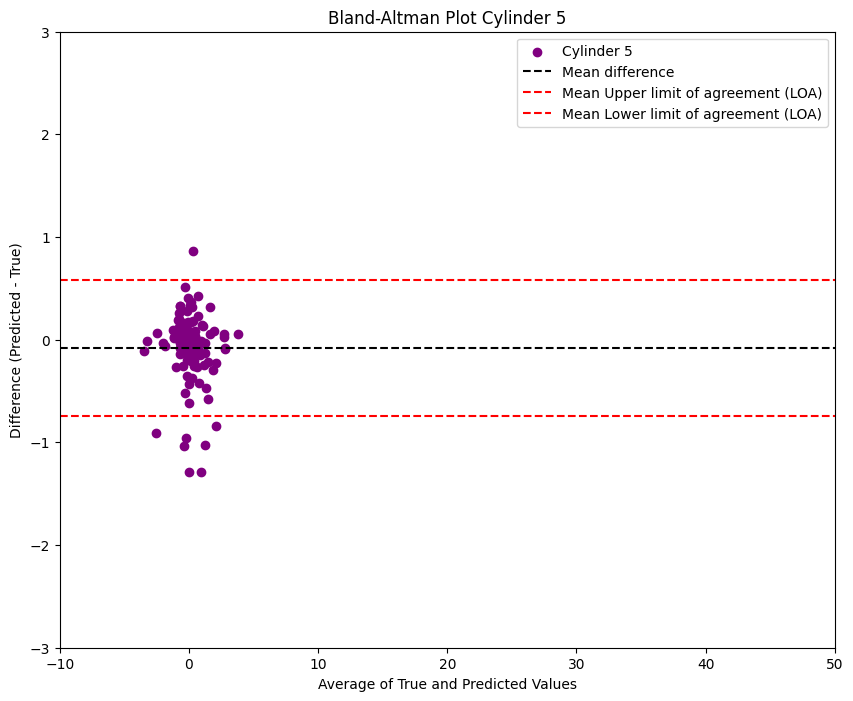

In [101]:
plt.figure(figsize=(10, 8))
plt.scatter(differences['unet_average_5'], differences['unet_difference_5'], color='purple', label='Cylinder 5')
plt.axhline(y=mean_difference5, color='black', linestyle='--', label='Mean difference')
plt.axhline(y=loa_upper5, color='red', linestyle='--', label='Mean Upper limit of agreement (LOA)')
plt.axhline(y=loa_lower5, color='red', linestyle='--', label='Mean Lower limit of agreement (LOA)')

# Adding labels and title
plt.xlabel('Average of True and Predicted Values')
plt.ylabel('Difference (Predicted - True)')
plt.title('Bland-Altman Plot Cylinder 5')
plt.xlim(-10, 50)
plt.ylim(-3, 3)
plt.legend()
plt.show()

In [102]:
print("Cylinder 1: ")
print("Mean Difference: ", mean_difference1)
print("Limits of Agreement: ", loa_upper1, loa_lower1)
print(loa_upper1 - mean_difference1)

print("Cylinder 2: ")
print("Mean Difference: ", mean_difference2)
print("Limits of Agreement: ", loa_upper2, loa_lower2)
print(loa_upper2 - mean_difference2)

print("Cylinder 3: ")
print("Mean Difference: ", mean_difference3)
print("Limits of Agreement: ", loa_upper3, loa_lower3)
print(loa_upper3 - mean_difference3)

print("Cylinder 4: ")
print("Mean Difference: ", mean_difference4)
print("Limits of Agreement: ", loa_upper4, loa_lower4)
print(loa_upper4 - mean_difference4)

print("Cylinder 5: ")
print("Mean Difference: ", mean_difference5)
print("Limits of Agreement: ", loa_upper5, loa_lower5)
print(loa_upper5 - mean_difference5)

print("Average: ")
print("Mean Difference: ", mean_difference)
print("Limits of Agreement: ", mean_loa_upper, mean_loa_lower)
print(mean_loa_upper - mean_difference)

Cylinder 1: 
Mean Difference:  -0.11538694869418553
Limits of Agreement:  1.3086130097151272 -1.5393869071034985
1.4239999584093126
Cylinder 2: 
Mean Difference:  -0.024704484020787506
Limits of Agreement:  1.0679608062550143 -1.1173697742965893
1.0926652902758018
Cylinder 3: 
Mean Difference:  -0.10081274852029287
Limits of Agreement:  1.0087196240680059 -1.2103451211085914
1.1095323725882986
Cylinder 4: 
Mean Difference:  -0.05604315420491664
Limits of Agreement:  0.9227934190585191 -1.0348797274683523
0.9788365732634358
Cylinder 5: 
Mean Difference:  -0.07696978267470835
Limits of Agreement:  0.5864104284471369 -0.7403499937965535
0.6633802111218452
Average: 
Mean Difference:  -0.07478342362297817
Limits of Agreement:  0.9788994575087608 -1.1284663047547172
1.053682881131739
